# Personal Project: Hospital Provider Cost Reports

## Exploratory Data Analysis on Hospital Provider Cost Reports

### Introduction
This project analyzes **Hospital Provider Cost Reports** published between 2011 and 2022. The dataset includes annual hospital cost reporting files, which were combined into a single consolidated dataset for analysis.

Our primary objective is to perform a comprehensive analysis of hospital provider cost report data to identify patterns, trends, and potential areas for improvement. This work will serve as a learning exercise to strengthen my data analysis skills and will result in a polished portfolio piece showcasing my ability to transform raw data into actionable insights.

📂 **Data Source**: [CMS Hospital Provider Cost Report](https://data.cms.gov/provider-compliance/cost-report/hospital-provider-cost-report)

### Research Questions
The following questions guide the analysis of hospital cost report data, with emphasis on financial performance, capacity, and care delivery trends across hospitals and regions.  

Financial Performance
- How has hospital net income changed over time, both nationally and by state?
- What is the average cost-to-charge ratio across hospitals, and which hospitals are outliers?
- How has the cost-to-charge ratio evolved over the years?
- How do urban vs. rural hospitals differ in financial performance trends?
- What are the long-term trends in assets, liabilities, and fund balances?

Capacity & Operations
- Which states or counties have the highest hospital capacity in terms of beds and patient days?
- How has staffing (FTE employees) changed relative to patient volume?

Care Delivery & Equity
- What are the trends in charity care and uncompensated care over time?
- How much uncompensated care is provided by region or hospital type?
- How do inpatient vs. outpatient revenues vary by hospital size and type?

### Who is the intended audience?
The insights will be tailored to meet the needs of several stakeholder groups:
- Hospital administrators and executives – to inform operational and financial decision-making
- Researchers & analysts – to serve as a reference point for further studies
- General public & patient advocates – to promote understanding of healthcare costs and trends
- Policy makers and government agencies – to guide regulation, funding allocation, and healthcare reform initiatives

### Type of Analyses
Descriptive analysis:
- Visualize cost distribution by department and facility characteristics
- Analyze Medicare settlement trends and utilization data
- Explore patterns that might indicate cost drivers or inefficiencies

Financial insights:
- Highlight key KPIs like cost-to-reimbursement ratios
- Detect and flag unusual cost spikes or trends in expenses
- Provide easy-to-understand summaries for quick decision-making

Marketing/strategy angle:
- Benchmark facilities against each other on cost efficiency
- Show utilization strengths in high-demand services
- Present geographic and service-line heatmaps for competitive insights

### Preparing the Environment

We will import the required libraries and read in the data set.
- Pandas - Data Manipulation
- Matplotlib - Data Visualization
- Seaborn - Data Visualization
- Warnings - Utility usage libraries

In [1]:
# Import libraries and alias for easy reading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re

In [2]:
# Suppress all warning messages to keep the output clean
warnings.filterwarnings('ignore')

# Configure plot styles: use matplotlib's default style
plt.style.use("default")

# Apply seaborn's theme for better-looking plots
sns.set_theme()

# Display all columns when printing DataFrames
pd.set_option("display.max_columns", None)

# Set the number of decimal places to display in DataFrames
pd.set_option("display.precision", 2)

In [3]:
# File path for the CSV data (replace with your own path if needed)
file_path = "C:/Users/Jason/Documents/Documents/Projects/Hospital_Provider_Cost_Report/Data/interim/hospital_provider_cost_output.csv"

# Read/load data in CSV format into a pandas DataFrame for analysis
hospital_provider_cost_data_raw = pd.read_csv(file_path)

### Data Source & Preparation

The dataset comes from annual Hospital Provider Cost Reports, published between 2011 and 2022. Each year was originally provided as a separate CSV file (such as `CostReport_2011_Final.csv`, `CostReport_2012_Final.csv`, `CostReport_2022_Final.csv`).  

To simplify the analysis, these files were combined into a **single consolidated dataset**.  
A preprocessing script (`merge_hospital_provider_cost_report_data.py`) was used to:
- Load all CSV files from 2011–2022
- Extract the year from the filename
- Add a new column `Cost Report Year`
- Merge them into one unified dataset
- Save the result as `hospital_provider_cost_output.csv`

This consolidated file is what we use for all further analysis.

### Data Exploration
Let's have a look at the data using df.head() and df.tail() function.

In [4]:
# Display the first 5 rows of the dataset
hospital_provider_cost_data_raw.head()

,rpt_rec_num,Provider CCN,Hospital Name,Street Address,City,State Code,Zip Code,County,Medicare CBSA Number,Rural Versus Urban,CCN Facility Type,Provider Type,Type of Control,Fiscal Year Begin Date,Fiscal Year End Date,FTE - Employees on Payroll,Number of Interns and Residents (FTE),Total Days Title V,Total Days Title XVIII,Total Days Title XIX,Total Days (V + XVIII + XIX + Unknown),Number of Beds,Total Bed Days Available,Total Discharges Title V,Total Discharges Title XVIII,Total Discharges Title XIX,Total Discharges (V + XVIII + XIX + Unknown),Number of Beds + Total for all Subproviders,Hospital Total Days Title V For Adults & Peds,Hospital Total Days Title XVIII For Adults & Peds,Hospital Total Days Title XIX For Adults & Peds,Hospital Total Days (V + XVIII + XIX + Unknown) For Adults & Peds,Hospital Number of Beds For Adults & Peds,Hospital Total Bed Days Available For Adults & Peds,Hospital Total Discharges Title V For Adults & Peds,Hospital Total Discharges Title XVIII For Adults & Peds,Hospital Total Discharges Title XIX For Adults & Peds,Hospital Total Discharges (V + XVIII + XIX + Unknown) For Adults & Peds,Cost of Charity Care,Total Bad Debt Expense,Cost of Uncompensated Care,Total Unreimbursed and Uncompensated Care,Total Salaries From Worksheet A,Overhead Non-Salary Costs,Depreciation Cost,Total Costs,Inpatient Total Charges,Outpatient Total Charges,Combined Outpatient + Inpatient Total Charges,Wage-Related Costs (Core),Wage-Related Costs (RHC/FQHC),Total Salaries (adjusted),Contract Labor: Direct Patient Care,Wage Related Costs for Part - A Teaching Physicians,Wage Related Costs for Interns and Residents,Cash on Hand and in Banks,Temporary Investments,Notes Receivable,Accounts Receivable,Less: Allowances for Uncollectible Notes and Accounts Receivable,Inventory,Prepaid Expenses,Other Current Assets,Total Current Assets,Land,Land Improvements,Buildings,Leasehold Improvements,Fixed Equipment,Major Movable Equipment,Minor Equipment Depreciable,Health Information Technology Designated Assets,Total Fixed Assets,Investments,Other Assets,Total Other Assets,Total Assets,Accounts Payable,"Salaries, Wages, and Fees Payable",Payroll Taxes Payable,Notes and Loans Payable (Short Term),Deferred Income,Other Current Liabilities,Total Current Liabilities,Mortgage Payable,Notes Payable,Unsecured Loans,Other Long Term Liabilities,Total Long Term Liabilities,Total Liabilities,General Fund Balance,Total Fund Balances,Total Liabilities and Fund Balances,DRG Amounts Other Than Outlier Payments,DRG Amounts Before October 1,DRG Amounts After October 1,Outlier Payments For Discharges,Disproportionate Share Adjustment,Allowable DSH Percentage,Managed Care Simulated Payments,Total IME Payment,Inpatient Revenue,Outpatient Revenue,Total Patient Revenue,Less Contractual Allowance and Discounts on Patients' Accounts,Net Patient Revenue,Less Total Operating Expense,Net Income from Service to Patients,Total Other Income,Total Income,Total Other Expenses,Net Income,Cost To Charge Ratio,Net Revenue from Medicaid,Medicaid Charges,Net Revenue from Stand-Alone CHIP,Stand-Alone CHIP Charges,Cost Report Year
0,285,10005,MARSHALL MEDICAL CENTER - SOUTH,2505 U.S. HIGHWAY 431,BOAZ,AL,35957-,MARSHALL,13820.0,R,STH,1,9,10/01/2010,09/30/2011,598.72,NaN,NaN,9132.0,4591.0,19641.0,114.0,41610.0,NaN,2109.0,1134.0,5283.0,114.0,NaN,7508.0,3073.0,15068.0,102.0,37230.0,NaN,2109.0,1134.0,5283.0,1.31e+06,NaN,1.13e+06,1.44e+06,2.67e+07,4.47e+07,5.08e+06,5.80e+07,6.86e+07,1.39e+08,2.08e+08,6.97e+06,NaN,2.67e+07,983584.0,NaN,NaN,6.88e+06,NaN,NaN,6.38e+06,NaN,564530.0,190283.0,1.30e+06,1.53e+07,1.97e+06,2.70e+06,7.63e+07,NaN,6.32e+06,4.93e+07,42937.0,NaN,5.65e+07,NaN,3.75e+07,3.75e+07,1.09e+08,4.10e+06,2.60e+06,NaN,NaN,NaN,-5.69e+06,1.01e+06,1.29e+07,NaN,NaN,4.81e+04,1.30e+07,1.40e+07,9.53e+07,9.53e+07,1.09e+08,1.27e+07,NaN,NaN,23664.0,2.18e+06,0.17,NaN,NaN,7.07e+07,1.50e+08,2.21e+08,1.58e+08,6.33e+07,7.13e+07,-8.02e+06,5.33e+06,-2.69e+06,NaN,-2.69e+06,0.28,8.36e+06,3.06e+

In [5]:
# Display the last 5 rows of the dataset
hospital_provider_cost_data_raw.tail()

,rpt_rec_num,Provider CCN,Hospital Name,Street Address,City,State Code,Zip Code,County,Medicare CBSA Number,Rural Versus Urban,CCN Facility Type,Provider Type,Type of Control,Fiscal Year Begin Date,Fiscal Year End Date,FTE - Employees on Payroll,Number of Interns and Residents (FTE),Total Days Title V,Total Days Title XVIII,Total Days Title XIX,Total Days (V + XVIII + XIX + Unknown),Number of Beds,Total Bed Days Available,Total Discharges Title V,Total Discharges Title XVIII,Total Discharges Title XIX,Total Discharges (V + XVIII + XIX + Unknown),Number of Beds + Total for all Subproviders,Hospital Total Days Title V For Adults & Peds,Hospital Total Days Title XVIII For Adults & Peds,Hospital Total Days Title XIX For Adults & Peds,Hospital Total Days (V + XVIII + XIX + Unknown) For Adults & Peds,Hospital Number of Beds For Adults & Peds,Hospital Total Bed Days Available For Adults & Peds,Hospital Total Discharges Title V For Adults & Peds,Hospital Total Discharges Title XVIII For Adults & Peds,Hospital Total Discharges Title XIX For Adults & Peds,Hospital Total Discharges (V + XVIII + XIX + Unknown) For Adults & Peds,Cost of Charity Care,Total Bad Debt Expense,Cost of Uncompensated Care,Total Unreimbursed and Uncompensated Care,Total Salaries From Worksheet A,Overhead Non-Salary Costs,Depreciation Cost,Total Costs,Inpatient Total Charges,Outpatient Total Charges,Combined Outpatient + Inpatient Total Charges,Wage-Related Costs (Core),Wage-Related Costs (RHC/FQHC),Total Salaries (adjusted),Contract Labor: Direct Patient Care,Wage Related Costs for Part - A Teaching Physicians,Wage Related Costs for Interns and Residents,Cash on Hand and in Banks,Temporary Investments,Notes Receivable,Accounts Receivable,Less: Allowances for Uncollectible Notes and Accounts Receivable,Inventory,Prepaid Expenses,Other Current Assets,Total Current Assets,Land,Land Improvements,Buildings,Leasehold Improvements,Fixed Equipment,Major Movable Equipment,Minor Equipment Depreciable,Health Information Technology Designated Assets,Total Fixed Assets,Investments,Other Assets,Total Other Assets,Total Assets,Accounts Payable,"Salaries, Wages, and Fees Payable",Payroll Taxes Payable,Notes and Loans Payable (Short Term),Deferred Income,Other Current Liabilities,Total Current Liabilities,Mortgage Payable,Notes Payable,Unsecured Loans,Other Long Term Liabilities,Total Long Term Liabilities,Total Liabilities,General Fund Balance,Total Fund Balances,Total Liabilities and Fund Balances,DRG Amounts Other Than Outlier Payments,DRG Amounts Before October 1,DRG Amounts After October 1,Outlier Payments For Discharges,Disproportionate Share Adjustment,Allowable DSH Percentage,Managed Care Simulated Payments,Total IME Payment,Inpatient Revenue,Outpatient Revenue,Total Patient Revenue,Less Contractual Allowance and Discounts on Patients' Accounts,Net Patient Revenue,Less Total Operating Expense,Net Income from Service to Patients,Total Other Income,Total Income,Total Other Expenses,Net Income,Cost To Charge Ratio,Net Revenue from Medicaid,Medicaid Charges,Net Revenue from Stand-Alone CHIP,Stand-Alone CHIP Charges,Cost Report Year
73969,776749,251325,COVINGTON COUNTY HOSPITAL,803 GERALD MCRANEY DRIVE,COLLINS,MS,39428,COVINGTON,25620.0,U,CAH,1,9,10/01/2021,09/30/2022,263.92,NaN,NaN,3316.0,1.0,4872.0,25.0,9125.0,NaN,64.0,11.0,124.0,35.0,NaN,235.0,1.0,441.0,25.0,9125.0,NaN,64.0,11.0,124.0,1.00e+00,8.21e+04,2.87e+04,7.10e+05,2.04e+07,2.20e+07,6.71e+05,3.07e+07,9.29e+06,4.45e+07,5.38e+07,NaN,NaN,NaN,NaN,NaN,NaN,7.85e+06,NaN,NaN,1.04e+07,-5.93e+06,8.71e+05,3.09e+05,1.18e+06,1.53e+07,2.90e+05,NaN,NaN,NaN,NaN,1.07e+07,NaN,NaN,1.12e+07,NaN,NaN,NaN,2.65e+07,6.85e+05,NaN,NaN,8.20e+05,NaN,2.86e+06,4.37e+06,NaN,5.18e+06,NaN,NaN,5.18e+06,9.55e+06,1.70e+07,1.70e+07,2.65e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.72e+07,4.60e+07,6.32e+07,2.96e+07,3.37e+07,4.25e+07,-8.84e+06,9.72e+06,8.84e+05,NaN,8.84e+05,0.57,1.26e+06,3.99e+06,NaN,NaN,2022
73970,776764,330273,PUTNAM HOSPITAL CENTER,670 STONELEIGH

You can see that the dataset contains a mix of categorical, geographical, and numerical variables.

Each record (row) corresponds to a hospital’s annual Medicare cost report submission for a specific fiscal year. The dataset captures:

- Operational statistics (beds, employees, interns/residents)
- Utilization metrics (patient days, discharges, inpatient vs. outpatient activity)
- Financial performance (costs, charges, revenues, charity care, uncompensated care, net income)
- Geographical details (city, state, county, rural vs. urban classification)
- Organizational attributes (facility type, ownership/control type, teaching status)

Next, we will use df.shape and df.info() to explore the dataset’s dimensions and variable types in more detail.

### Data Validation

In this step, I validated the integrity and structure of the dataset before cleaning.  
Validation tasks included:  

- Checking the shape of the dataset (rows and columns)  
- Reviewing column names and data types  
- Generating descriptive statistics for numerical fields  
- Summarizing the dataset (info, unique values, distributions)  
- Counting missing values per column and calculating percentages  

These checks ensure the dataset is complete, consistent, and properly structured before proceeding with cleaning and analysis.

In [6]:
# Shape of the data set (rows, columns)
print("Shape of dataset:", hospital_provider_cost_data_raw.shape)

Shape of dataset: (73974, 118)


In [7]:
# Summarised information of data set
hospital_provider_cost_data_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73974 entries, 0 to 73973
Columns: 118 entries, rpt_rec_num to Cost Report Year
dtypes: float64(103), int64(5), object(10)
memory usage: 66.6+ MB


There are 73,974 rows including header and 118 columns. Data type is correct and matches the corresponding values.

In [8]:
# Column names and data types
print("\nColumn Info:")
print(hospital_provider_cost_data_raw.dtypes)


Column Info:
rpt_rec_num                            int64
Provider CCN                           int64
Hospital Name                         object
Street Address                        object
City                                  object
                                      ...   
Net Revenue from Medicaid            float64
Medicaid Charges                     float64
Net Revenue from Stand-Alone CHIP    float64
Stand-Alone CHIP Charges             float64
Cost Report Year                       int64
Length: 118, dtype: object


In [9]:
# Quick descriptive stats (numeric only)
print("\nDescriptive Statistics (numeric columns):")
display(hospital_provider_cost_data_raw.describe().T)


Descriptive Statistics (numeric columns):


,count,mean,std,min,25%,50%,75%,max
rpt_rec_num,73974.0,6.78e+05,8.53e+04,2.85e+02,6.19e+05,6.96e+05,7.48e+05,7.77e+05
Provider CCN,73974.0,2.69e+05,1.58e+05,1.00e+04,1.40e+05,2.60e+05,3.92e+05,7.13e+05
Medicare CBSA Number,73048.0,5.37e+04,3.42e+04,1.00e+00,2.64e+04,3.97e+04,9.99e+04,1.00e+05
Provider Type,73974.0,1.72e+00,1.55e+00,1.00e+00,1.00e+00,1.00e+00,1.00e+00,1.10e+01
Type of Control,73974.0,4.23e+00,3.22e+00,1.00e+00,2.00e+00,4.00e+00,5.00e+00,1.30e+01
...,...,...,...,...,...,...,...,...
Net Revenue from Medicaid,54482.0,2.38e+07,1.61e+08,-2.69e+07,1.86e+06,6.45e+06,2.01e+07,3.11e+10
Medicaid Charges,54457.0,1.27e+08,2.92e+08,-2.12e+07,6.79e+06,3.26e+07,1.24e+08,1.57e+10
Net Revenue from Stand-Alone CHIP,12037.0,7.81e+05,4.38e+06,-9.51e+04,2.53e+04,9.40e+04,3.58e+05,3.00e+08
Stand-Alone CHIP Charges,12218.0,3.75e+06,1.77e+07,-1.05e+06,1.17e+05,4.96e+05,1.96e+06,8.85e+08


In [10]:
# Quick descriptive stats (categorical only)
print("\nDescriptive Statistics (categorical columns):")
display(hospital_provider_cost_data_raw.describe(include=['O']).T)


Descriptive Statistics (categorical columns):


,count,unique,top,freq
Hospital Name,73974,9118,ENCOMPASS HEALTH REHABILITATION HOSP,485
Street Address,73916,8543,444 LAFAYETTE ROAD,102
City,73974,3418,HOUSTON,506
State Code,73974,56,TX,7123
Zip Code,73974,6795,55164-0979,102
County,70162,1899,LOS ANGELES,1180
Rural Versus Urban,73048,2,U,44409
CCN Facility Type,73974,8,STH,40901
Fiscal Year Begin Date,73974,955,01/01/2022,2456
Fiscal Year End Date,73974,746,12/31/2021,2457


In [11]:
# Count of missing values per column
print("\nMissing Values per Column:")
print(hospital_provider_cost_data_raw.isnull().sum())


Missing Values per Column:
rpt_rec_num                              0
Provider CCN                             0
Hospital Name                            0
Street Address                          58
City                                     0
                                     ...  
Net Revenue from Medicaid            19492
Medicaid Charges                     19517
Net Revenue from Stand-Alone CHIP    61937
Stand-Alone CHIP Charges             61756
Cost Report Year                         0
Length: 118, dtype: int64


In [12]:
# Percentage of missing values
print("\nPercentage Missing:")
print((hospital_provider_cost_data_raw.isnull().sum() / len(hospital_provider_cost_data_raw) * 100).round(2))


Percentage Missing:
rpt_rec_num                           0.00
Provider CCN                          0.00
Hospital Name                         0.00
Street Address                        0.08
City                                  0.00
                                     ...  
Net Revenue from Medicaid            26.35
Medicaid Charges                     26.38
Net Revenue from Stand-Alone CHIP    83.73
Stand-Alone CHIP Charges             83.48
Cost Report Year                      0.00
Length: 118, dtype: float64


### Data Cleaning & Preprocessing

Before conducting exploratory data analysis (EDA), it was necessary to ensure the dataset was accurate, consistent, and ready for analysis.  
Raw healthcare provider data often contained missing values, inconsistent formatting, duplicate records, non-standard codes, and accounting sign conventions in financial fields.

The cleaning and preprocessing process addressed these issues through the following steps:

- Handling missing and blank values  
- Standardizing categorical fields (such as county, provider type, rural vs. urban)  
- Correcting formatting issues in ZIP codes and addresses  
- Removing or replacing invalid or corrupted entries  
- Expanding abbreviations and replacing numeric codes with descriptive labels  
- Validating numerical fields, correcting sign conventions, and rounding where appropriate  
- Recalculating totals from cleaned sub-accounts to ensure balance sheet integrity  

To demonstrate versatility, I applied a **hybrid approach using both Excel and Python**:
- **Excel** was used for quick inspection and manual cleaning of categorical and text-based fields (such as addresses, county names, ZIP codes, provider type mappings).  
- **Python (Pandas)** was used for scalable, reproducible cleaning of large datasets, particularly financial fields (such as standardizing revenue and expense signs, recalculating totals, and applying consistent rules across multiple years).  

*Data Cleaning Workflow*

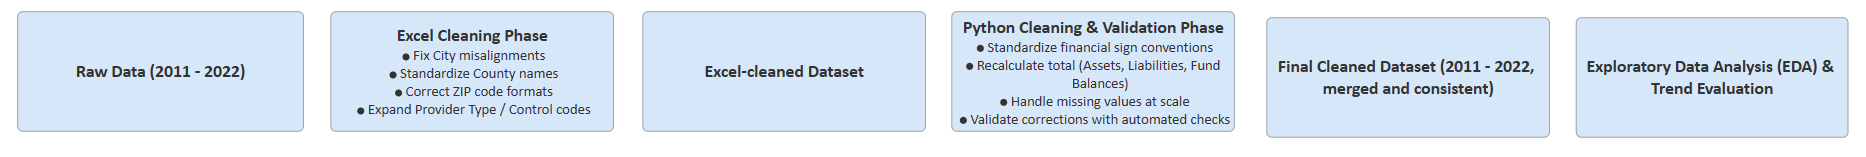

**Note on Workflow:**

- The initial round of cleaning was performed in **Excel** to address text-based and categorical issues:  
  - City misalignment  
  - ZIP code formatting  
  - County standardization  

- The **Excel-cleaned dataset** was then imported into **Python** for additional cleaning, validation, and scalable preprocessing, including:  
  - Handling financial sign conventions  
  - Recalculating totals (Assets, Liabilities, Fund Balances)  
  - Running quality checks across all reporting years  

- This hybrid process ensured:  
  - **Transparency** → Excel for visual inspection and manual corrections  
  - **Reproducibility** → Python for systematic, programmatic cleaning  

- By combining Excel’s strengths in inspection with Python’s automation and validation, I produced a **merged dataset (2011–2022)** that is consistent and reliable.  

- The cleaned dataset provides a solid foundation for **exploratory data analysis (EDA)** and **trend evaluation** in the following sections.

#### City Column Cleanup
During validation, I discovered that the **City** column contained some full street addresses due to a misaligned import.  

**Steps Taken in Excel**  
1. Applied the filter option to review distinct values in the City column.  
2. Performed a quick scan to identify values that looked like addresses instead of city names.  
3. For affected records, manually realigned the fields:  
   - Moved the address from the City column back into the Street Address column.  
   - Cleared the incorrect value in City.  
4. Repopulated City where possible using ZIP → City crosswalks, and spot-checked ambiguous cases using Google Maps for verification.  

Before: Misaligned City Values (Raw Data)

Some provider records contained full street addresses in the **City** column due to a misaligned import. The table below displays the affected **Provider CCN IDs** (`50262`, `50751`, `100017`) with selected attributes to illustrate the issue. Notice that the **City** field incorrectly contains address values, while the **Street Address** field contains hospital names.


In [13]:
# === BEFORE: Show misaligned City values (raw data) ===
# Goal: Display only the affected providers and the key fields to illustrate the issue.

# Columns to display
cols = ["rpt_rec_num", "Provider CCN", "Hospital Name", "Street Address", "City", "State Code"]

# Provider CCNs with suspected misalignment
affected_ccns = [50262, 50751, 100017]

# Filter to affected providers (raw data)
before_view = (hospital_provider_cost_data_raw.loc[hospital_provider_cost_data_raw["Provider CCN"].isin(affected_ccns), cols].sort_values(by=["Provider CCN", "City"]).reset_index(drop=True))

before_view

,rpt_rec_num,Provider CCN,Hospital Name,Street Address,City,State Code
0,763398,50262,RONALD REAGAN UCLA MEDICAL CENTER,RONALD REAGAN UCLA MEDICAL CENTER,757 WESTWOOD PLAZA,CA
1,700191,50262,RONALD REAGAN UCLA MEDICAL CENTER,RONALD REAGAN UCLA MEDICAL CENTER,757 WESTWOOD PLAZA,CA
2,764372,50262,RONALD REAGAN UCLA MEDICAL CENTER,RONALD REAGAN UCLA MEDICAL CENTER,757 WESTWOOD PLAZA,CA
3,763807,50262,RONALD REAGAN UCLA MEDICAL CENTER,757 WESTWOOD PLAZA,LOS ANGELES,CA
4,546554,50262,RONALD REAGAN UCLA MEDICAL CENTER,757 WESTWOOD PLAZA,LOS ANGELES,CA
5,773512,50262,RONALD REAGAN UCLA MEDICAL CENTER,757 WESTWOOD PLAZA,LOS ANGELES,CA
6,742300,50262,RONALD REAGAN UCLA,757 WESTWOOD PLAZA,LOS ANGELES,CA
7,764373,50262,RONALD REAGAN UCLA,757 WESTWOOD PLAZA,LOS ANGELES,CA
8,762025,50262,RONALD REAGAN UCLA,757 WESTWOOD PLAZA,LOS ANGELES,CA
9,739947,50262,RONALD REAGAN UCLA,757 WESTWOOD PLAZA,LOS ANGELES,CA


In [14]:
# === Load Cleaned Dataset ===
# File path for the cleaned CSV (update if needed for your environment)
file_path_cleaned = ("C:/Users/Jason/Documents/Documents/Projects/Hospital_Provider_Cost_Report/Data/interim/hospital_provider_cost_output_cleaned.csv")

# Read the cleaned data into a pandas DataFrame for analysis
hospital_provider_cost_data_clean = pd.read_csv(file_path_cleaned)

In [15]:
# === AFTER: Verify City is corrected (post-cleaning) ===

after_view = (hospital_provider_cost_data_clean.loc[hospital_provider_cost_data_clean["Provider CCN"].isin(affected_ccns), cols].sort_values(by=["Provider CCN", "City"]).reset_index(drop=True))

after_view

,rpt_rec_num,Provider CCN,Hospital Name,Street Address,City,State Code
0,546554,50262,RONALD REAGAN UCLA MEDICAL CENTER,757 WESTWOOD PLAZA,LOS ANGELES,CA
1,700191,50262,RONALD REAGAN UCLA MEDICAL CENTER,757 WESTWOOD PLAZA,LOS ANGELES,CA
2,739947,50262,RONALD REAGAN UCLA,757 WESTWOOD PLAZA,LOS ANGELES,CA
3,742300,50262,RONALD REAGAN UCLA,757 WESTWOOD PLAZA,LOS ANGELES,CA
4,759418,50262,RONALD REAGAN UCLA,757 WESTWOOD PLAZA,LOS ANGELES,CA
5,762025,50262,RONALD REAGAN UCLA,757 WESTWOOD PLAZA,LOS ANGELES,CA
6,763398,50262,RONALD REAGAN UCLA MEDICAL CENTER,757 WESTWOOD PLAZA,LOS ANGELES,CA
7,763807,50262,RONALD REAGAN UCLA MEDICAL CENTER,757 WESTWOOD PLAZA,LOS ANGELES,CA
8,764372,50262,RONALD REAGAN UCLA MEDICAL CENTER,757 WESTWOOD PLAZA,LOS ANGELES,CA
9,764373,50262,RONALD REAGAN UCLA,757 WESTWOOD PLAZA,LOS ANGELES,CA


#### Zip Code Column Cleaning

The raw dataset contained ZIP codes with trailing dashes (e.g., `35957-`) or full ZIP+4 formats (e.g., `36106-1109`).  
For consistency, I standardized all ZIP codes to the **5-digit format** by keeping only the first five characters.  

This ensures that geographic analysis (e.g., grouping by county or city) uses a uniform ZIP code format and avoids mismatches caused by extra digits or trailing symbols.

In [16]:
# Clean Zip Code column: keep only first 5 characters
hospital_provider_cost_data_clean["Zip Code"] = (hospital_provider_cost_data_clean["Zip Code"].astype(str).str[:5])

# Validate: check unique values
hospital_provider_cost_data_clean["Zip Code"].unique()[:20]

array(['36301', '35957', '35630', '36462', '36049', '35640', '35976',
       '35235', '35967', '36784', '35007', '35233', '35660', '36360',
       '35960', '36116', '36106', '36854', '35323', '36802'], dtype=object)

#### County Column Cleaning

In [ ]:
SPECIAL_CASES = {
    r"\BACA": "BACA",  # if this literal appears; if unintended, remove this line
    "ACADIA PARISH": "ACADIA",
    "ALLEGAN": "ALLEGAN",
    "ALLEGANY": "ALLEGANY",
    "ANCHORAGE MUNICIPALITY": "ANCHORAGE",  # canonical core name
    "ANCHRAGE": "ANCHORAGE",
    "ANDROSCOGGIN": "ANDROSCOGGIN",
    "ARAPAHOE": "ARAPAHOE",
    "ARAPAOE": "ARAPAHOE",
    "ASCENSION": "ASCENSION",
    "ASCENSION PARISH": "ASCENSION",
    "AVOYELLES PARISH": "AVOYELLES",
    "BALTIIMORE CITY": "BALTIMORE CITY",
    "BALTIMORE CITY": "BALTIMORE CITY",    # keep CITY since it’s distinct from county
    "BALTIMORE COUNTY": "BALTIMORE",       # county -> core
    "BAY COUNTY": "BAY",
    "BIENVILLE PARISH": "BIENVILLE",
    "BONNEVILLE": "BONNEVILLE",
    "BONNIEVILLE": "BONNEVILLE",
    "BOSSIER PARISH": "BOSSIER",
    "BREVARD": "BREVARD",
    "BREVARDY": "BREVARD",
    "CADDO PARISH": "CADDO",
    "CADDO PARRISH": "CADDO",
    "CALCASIEU PARISH": "CALCASIEU",
    "CALDWELL PARISH": "CALDWELL",
    "CONCORDIA PARISH": "CONCORDIA",
    "COOK COUNTY": "COOK",
    "CRAWFORD COUNTY": "CRAWFORD",
    "DAVIESS": "DAVIESS",
    "DAVIS": "DAVIS",
    "E. BATON ROUGE PARISH": "EAST BATON ROUGE",
    "EAST BATON ROUGE PARISH": "EAST BATON ROUGE",
    "EAST BATON ROUGE PARRISH": "EAST BATON ROUGE",
    "EAST CARROLL PARISH": "EAST CARROLL",
    "EAST FELICIANA PARISH": "EAST FELICIANA",
    "FRANKLIN PARISH": "FRANKLIN",
    "FREEMONT": "FREMONT",
    "FRESNO CA": "FRESNO",
    "GRAND": "GRAND",
    "GRAND TRAVERSE": "GRAND TRAVERSE",
    "HARTFORD COUNTY": "HARTFORD",
    "IBERIA PARISH": "IBERIA",
    "IDA": "IDA",
    "INDIAN RIVER COUNTY": "INDIAN RIVER",
    "INYO": "INYO",
    "INYO CA": "INYO",
    "JEFFERSON DAVIS": "JEFFERSON DAVIS",
    "JEFFRSON DAVIS PARISH": "JEFFERSON DAVIS",
    "KENAI PENINSULA BOROUGH": "KENAI PENINSULA",
    "KENAI PENINSULA COUNTY": "KENAI PENINSULA",
    "LA SALLE PARISH": "LA SALLE",
    "LAFAYETTE PARISH": "LAFAYETTE",
    "LAFOURCHE PARISH": "LAFOURCHE",
    "LIMESTONE COUNTY": "LIMESTONE",
    "LINCOLN PARISH": "LINCOLN",
    "LITCHFIELD COUNTY": "LITCHFIELD",
    "LIVINGSTON PARISH": "LIVINGSTON",
    "LOS ANGELES CA": "LOS ANGELES",
    "LOS ANGLES": "LOS ANGELES",
    "MACOMB COUNTY": "MACOMB",
    "MADISON PARISH": "MADISON",
    "MATANUSKA-SUSITNA MUNICIPALITY": "MATANUSKA-SUSITNA",
    "MENDOCINO COUNTY CA": "MENDOCINO",
    "MONTCLAIM": "MONTCALM",  # likely intent (MI). If not, change as needed.
    "MOREHOUSE PARISH": "MOREHOUSE",
    "MUNICIPALITY OF ANCHORAGE": "ANCHORAGE",
    "NAPA COUNTY": "NAPA",
    "NATCHITOCHES PARISH": "NATCHITOCHES",
    "NAVAJO COUNTY": "NAVAJO",
    "ORANGE CALIFORNIA": "ORANGE",
    "ORANGE COUNTY": "ORANGE",
    "ORLEANS PARISH": "ORLEANS",
    "OTTER TAIL": "OTTER TAIL",
    "OTTERTAIL": "OTTER TAIL",
    "OUACHITA PARISH": "OUACHITA",
    "PINELLAS": "PINELLAS",
    "PINNELLAS": "PINELLAS",
    "PLACER COUNTY": "PLACER",
    "PLUMAS CA": "PLUMAS",
    "POINTE COUPEE PARISH": "POINTE COUPEE",
    "POTTAWATOMIE": "POTTAWATOMIE",       # distinct from POTTAWATTAMIE
    "POTTAWATTAMIE": "POTTAWATTAMIE",
    "PRINCE GEORGES COUNTY": "PRINCE GEORGE'S",
    "RAPIDES PARISH": "RAPIDES",
    "RAPIDS PARISH": "RAPIDES",
    "RED RIVER PARISH": "RED RIVER",
    "RICHLAND PARISH": "RICHLAND",
    "RIVER SIDE": "RIVERSIDE",
    "ROCKCASTLE": "ROCKCASTLE",
    "SABINE PARISH": "SABINE",
    "SAC": "SAC",
    "SAINT CLAIR COUNTY": "SAINT CLAIR",
    "SAN BENITO CA": "SAN BENITO",
    "SAN BERNADINO": "SAN BERNARDINO",
    "SAN BERNADINO CA": "SAN BERNARDINO",
    "SAN BERNANDINO COUNTY CA": "SAN BERNARDINO",
    "SAN DEIGO": "SAN DIEGO",
    "SAN DIEGO": "SAN DIEGO",
    "SAN DIEGO COUNTY": "SAN DIEGO",
    "SEBASTIANN": "SEBASTIAN",
    "SEBASTION": "SEBASTIAN",
    "SEDGWICK": "SEDGWICK",
    "SITKA BOROUGH": "SITKA",
    "SONOMA COUNTY": "SONOMA",
    "ST MARTIN PARISH": "SAINT MARTIN",
    "ST TAMMANY PARISH": "SAINT TAMMANY",
    "ST. CHARLES PARISH": "SAINT CHARLES",
    "ST. HELENA PARISH": "SAINT HELENA",
    "ST. JAMES PARISH": "SAINT JAMES",
    "ST. LANDRY PARISH": "SAINT LANDRY",
    "ST. MARTIN PARISH": "SAINT MARTIN",
    "ST. MARY PARISH": "SAINT MARY",
    "ST. TAMMANY PARISH": "SAINT TAMMANY",
    "ST.TAMMANY": "SAINT TAMMANY",
    "STATEWIDE PARISH": None,  # not a county
    "TANGIPAHOA PARISH": "TANGIPAHOA",
    "TERREBONE PARISH": "TERREBONNE",
    "TERREBONNE PARISH": "TERREBONNE",
    "TULARE COUNTY": "TULARE",
    "UNION PARISH": "UNION",
    "UNITED STATES": None,
    "USA": None,
    "VALDEZ-CORDOVA BOROUGH": "VALDEZ-CORDOVA",  # keep historical name unless you want AK’s newer areas
    "VANDENBURGH": "VANDERBURGH",
    "VANDERBURGH": "VANDERBURGH",
    "VERMILION": "VERMILION",      # keep Louisiana style; see below for SAINT vs ST.
    "VERMILION PARISH": "VERMILION",
    "VERMILLION": "VERMILLION",
    "VERNON PARISH": "VERNON",
    "WABASH": "WABASH",
    "WALKER DADE AND CATOOSA": None,  # multi-county marker → manual handling
    "WALKER  DADE AND CATOOSA": None,
    "WASHINGTON PARISH": "WASHINGTON",
    "WAYNE COUNTY": "WAYNE",
    "WEBSTER PARISH": "WEBSTER",
    "WELD COUNTY": "WELD",
    "WEST FELICIANA PARISH": "WEST FELICIANA",
    "WRANGELL-PETERSBURG": "WRANGELL-PETERSBURG",
    "YELLOW MEDCINE": "YELLOW MEDICINE",
}

# Function to handle both regex and direct string replacements
def clean_county(county):
    if pd.isna(county):
        return county
    county = str(county).strip().upper()
    
    for k, v in SPECIAL_CASES.items():
        if v is None:  # drop these values
            if re.fullmatch(k, county) or county == k:
                return None
        else:
            # Regex check
            if k.startswith("r\""):  # if you intended regex
                pattern = k.strip('r"')
                if re.search(pattern, county):
                    return v
            # Exact match check
            if county == k:
                return v
    return county  # keep unchanged if no match

# Apply cleaning to County column
hospital_provider_cost_data_clean["County"] = hospital_provider_cost_data_clean["County"].apply(clean_county)
hospital_provider_cost_data_clean

In [20]:
# Look over issues log to find what columns / data needs to be cleaned

# Zip Code - 

# County

# Rural versus Urban

# CCN Facility Type

# Provider Type

# Type of Control

### Exploratory Data Analysis (EDA)

### Key Findings / Insights

### Limitations

### Next Steps / Future Work